# Active Learning for Emotion Classification in eCommerce Reviews
## A Comparative Study of Query Strategies, Classifiers, and Label Efficiency

**Author:** Hasan Iftikhar  
**Affiliation:** Independent Researcher, Belfast, United Kingdom  

---

### How to Run
1. Runtime → Change runtime type → **T4 GPU** (recommended)
2. Run cells **in order** from top to bottom
3. For Kaggle download (Cell 2): upload your `kaggle.json` when prompted
4. If you already have the pre-labelled CSV, set `DATA_PATH` in Cell 3

---

### Notebook Structure

| # | Cell | Description |
|---|------|-------------|
| 1 | Dependencies | Install pinned libraries |
| 2 | Data Download | Kaggle API download |
| 3 | Configuration | All hyperparameters and seeds |
| 4 | Data Loading | Load and explore dataset |
| 5 | Preprocessing | Clean text pipeline |
| 6 | Emotion Labelling | DistilRoBERTa inference (skips if labels exist) |
| 7 | Feature Extraction | TF-IDF + train/test split |
| 8 | Query Strategies | 4 AL strategies defined |
| 9 | Classifiers | LogReg, SVM, Naive Bayes defined |
| 10 | SSL Baseline | S3VM comparison from Paper 2 |
| 11 | AL Loop | Full experiment across strategies × classifiers |
| 12 | Results Tables | All metrics tabulated |
| 13 | Classification Reports | Full reports at 30% budget |
| 14 | Significance Testing | Wilcoxon signed-rank tests |
| 15 | Figure 1 | Learning curves |
| 16 | Figure 2 | Minority class F1 |
| 17 | Figure 3 | Confusion matrices |
| 18 | Figure 4 | Grouped bar chart |
| 19 | Figure 5 | Label efficiency |
| 20 | Figure 6 | Classifier comparison |
| 21 | Figure 7 | Significance heatmap |
| 22 | Key Findings | Summary of all results |

## Cell 1 — Install Dependencies

In [2]:
!pip install -q \
    scikit-learn==1.4.2 \
    pandas==2.2.2 \
    matplotlib==3.9.0 \
    seaborn==0.13.2 \
    scipy==1.13.0 \
    transformers==4.40.2 \
    kaggle==1.6.14

import sklearn, pandas, numpy, matplotlib, seaborn, scipy, transformers, torch
print(f'scikit-learn : {sklearn.__version__}')
print(f'pandas       : {pandas.__version__}')
print(f'numpy        : {numpy.__version__}')
print(f'scipy        : {scipy.__version__}')
print(f'matplotlib   : {matplotlib.__version__}')
print(f'seaborn      : {seaborn.__version__}')
print(f'transformers : {transformers.__version__}')
print(f'torch        : {torch.__version__}')
print(f'GPU available: {torch.cuda.is_available()}')
print('All dependencies installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 74.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, but you

## Cell 2 — Download Dataset from Kaggle

In [3]:
import os

# ── Upload kaggle.json (get from kaggle.com → Settings → API → Create New Token)
from google.colab import files
print('Upload your kaggle.json:')
uploaded = files.upload()

# Check if 'kaggle.json' was actually uploaded
if 'kaggle.json' in uploaded:
    os.makedirs('/root/.kaggle', exist_ok=True)
    os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)

    !kaggle datasets download -d nicapotato/womens-ecommerce-clothing-reviews --unzip -p /content/data/

    DATA_PATH = '/content/data/Womens Clothing E-Commerce Reviews.csv'
    print(f'Dataset downloaded to: {DATA_PATH}')
else:
    print("Error: 'kaggle.json' was not uploaded. Please upload your Kaggle API token file named 'kaggle.json'.")
    if uploaded:
        print(f"You uploaded the following files: {list(uploaded.keys())}. Please ensure 'kaggle.json' is among them.")
    # Exit or handle the error gracefully, for now, we'll just print a message.

Upload your kaggle.json:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews
License(s): CC0-1.0
100% 2.79M/2.79M [00:01<00:00, 3.52MB/s]
100% 2.79M/2.79M [00:01<00:00, 2.88MB/s]
Dataset downloaded to: /content/data/Womens Clothing E-Commerce Reviews.csv


## Cell 3 — Configuration and Reproducibility

In [4]:
import numpy as np
import random
import torch
import warnings
warnings.filterwarnings('ignore')

# ── If using pre-labelled CSV, set path here instead ──────────────────────
# DATA_PATH = '/content/drive/MyDrive/data7.csv'

# ── Reproducibility: fix all random seeds ─────────────────────────────────
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GLOBAL_SEED)

# ── Experiment hyperparameters ─────────────────────────────────────────────
BUDGETS       = [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]  # label budget fractions
N_RUNS        = 5       # runs per strategy/classifier (averaged + std)
QUERY_BATCH   = 30      # samples queried per AL iteration
MAX_FEATURES  = 3000    # TF-IDF vocabulary size
TEST_SIZE     = 0.20    # held-out test proportion
VALID_EMOTIONS= ['joy','sadness','neutral','surprise','fear','disgust','anger']
DEVICE        = 'cuda' if torch.cuda.is_available() else 'cpu'

print('Configuration:')
print(f'  GLOBAL_SEED   = {GLOBAL_SEED}')
print(f'  BUDGETS       = {BUDGETS}')
print(f'  N_RUNS        = {N_RUNS}')
print(f'  QUERY_BATCH   = {QUERY_BATCH}')
print(f'  MAX_FEATURES  = {MAX_FEATURES}')
print(f'  TEST_SIZE     = {TEST_SIZE}')
print(f'  DEVICE        = {DEVICE}')

Configuration:
  GLOBAL_SEED   = 42
  BUDGETS       = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
  N_RUNS        = 5
  QUERY_BATCH   = 30
  MAX_FEATURES  = 3000
  TEST_SIZE     = 0.2
  DEVICE        = cpu


## Cell 4 — Data Loading and Exploration

Dataset shape  : (23486, 11)
Columns        : ['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']
Missing reviews: 845


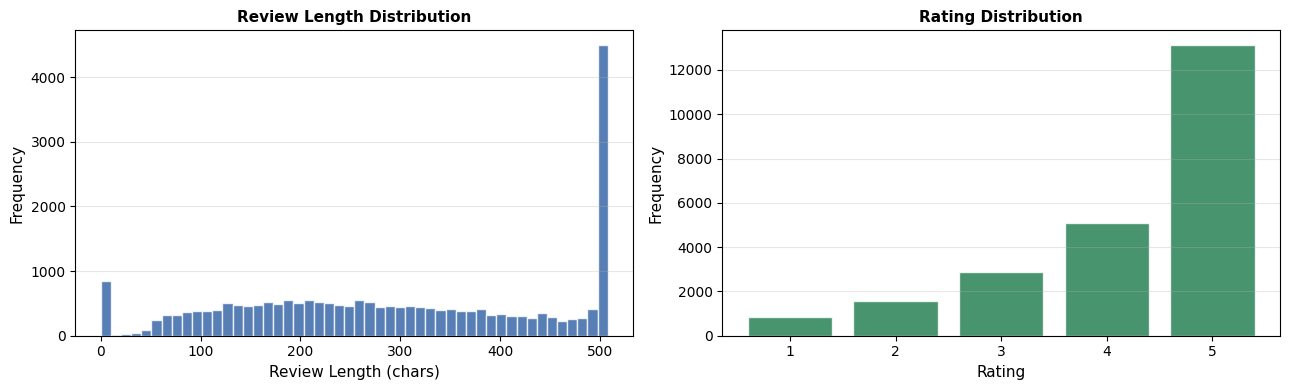

count    23486.0
mean       297.6
std        152.6
min          0.0
25%        173.0
50%        292.0
75%        451.0
max        508.0
Name: review_length, dtype: float64


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(DATA_PATH)
print(f'Dataset shape  : {df.shape}')
print(f'Columns        : {df.columns.tolist()}')
print(f'Missing reviews: {df["Review Text"].isna().sum():,}')

# Review length distribution
df['review_length'] = df['Review Text'].fillna('').str.len()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['review_length'].clip(0,600), bins=50,
             color='#2E5FA3', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Review Length (chars)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Review Length Distribution', fontsize=11, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

if 'Rating' in df.columns:
    rating_counts = df['Rating'].value_counts().sort_index()
    axes[1].bar(rating_counts.index.astype(str), rating_counts.values,
                color='#1A7A4A', alpha=0.8, edgecolor='white')
    axes[1].set_xlabel('Rating', fontsize=11)
    axes[1].set_ylabel('Frequency', fontsize=11)
    axes[1].set_title('Rating Distribution', fontsize=11, fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print(df['review_length'].describe().round(1))

## Cell 5 — Text Preprocessing

In [6]:
import re

STOP_WORDS = {
    'i','me','my','myself','we','our','ours','ourselves','you','your','yours',
    'yourself','yourselves','he','him','his','himself','she','her','hers',
    'herself','it','its','itself','they','them','their','theirs','themselves',
    'what','which','who','whom','this','that','these','those','am','is','are',
    'was','were','be','been','being','have','has','had','having','do','does',
    'did','doing','a','an','the','and','but','if','or','because','as','until',
    'while','of','at','by','for','with','about','against','between','into',
    'through','during','before','after','above','below','to','from','up','down',
    'in','out','on','off','over','under','again','further','then','once','here',
    'there','when','where','why','how','all','both','each','few','more','most',
    'other','some','such','no','nor','not','only','own','same','so','than',
    'too','very','s','t','can','will','just','should','now','d','ll','m',
    'o','re','ve','y','ain','aren','couldn','didn','doesn','hadn','hasn',
    'haven','isn','wasn','weren','won','wouldn','also','would','could',
    'about','into','than','then','there','when','where'
}

def clean_text(text):
    """
    Standard NLP preprocessing:
    - Remove HTML tags and URLs
    - Lowercase
    - Remove non-alphabetic characters
    - Remove short tokens (<3 chars)
    - Remove stopwords
    """
    if not isinstance(text, str): return ''
    text = re.sub(r'http\S+|<[^>]+>', '', text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return ' '.join(w for w in text.split()
                    if w not in STOP_WORDS and len(w) > 2)

df['clean_text'] = df['Review Text'].apply(clean_text)
df = df[df['clean_text'].str.len() > 10].reset_index(drop=True)
print(f'Reviews after preprocessing: {len(df):,}')
print('\nSample cleaned reviews:')
for i in range(2):
    print(f'  Original : {str(df["Review Text"].iloc[i])[:80]}...')
    print(f'  Cleaned  : {df["clean_text"].iloc[i][:80]}...')
    print()

Reviews after preprocessing: 22,632

Sample cleaned reviews:
  Original : Absolutely wonderful - silky and sexy and comfortable...
  Cleaned  : absolutely wonderful silky sexy comfortable...

  Original : Love this dress!  it's sooo pretty.  i happened to find it in a store, and i'm g...
  Cleaned  : love dress sooo pretty happened find store glad never ordered online petite boug...



## Cell 6 — Emotion Labelling via DistilRoBERTa

> **Note:** This cell runs DistilRoBERTa inference (~30-60 min on GPU).  
> It is **automatically skipped** if the `Emotions` column already exists in your CSV.

Running DistilRoBERTa on 22,632 reviews (device: cpu)...
  64/22,632 done...
  3,264/22,632 done...
  6,464/22,632 done...
  9,664/22,632 done...
  12,864/22,632 done...
  16,064/22,632 done...
  19,264/22,632 done...
  22,464/22,632 done...
Labelling complete.

Emotion distribution:
  joy          12364  (54.6%)
  sadness       3371  (14.9%)
  surprise      3009  (13.3%)
  neutral       2864  (12.7%)
  fear           652  (2.9%)
  anger          280  (1.2%)
  disgust         92  (0.4%)


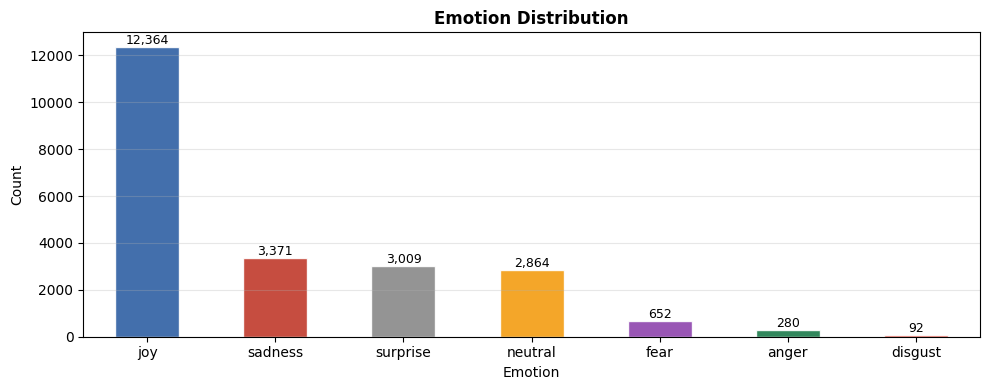

In [8]:
from transformers import pipeline

if 'Emotions' in df.columns and df['Emotions'].notna().sum() > 1000:
    print(f'Emotions column found: {df["Emotions"].notna().sum():,} labels present.')
    print('Skipping DistilRoBERTa inference.')
else:
    print(f'Running DistilRoBERTa on {len(df):,} reviews (device: {DEVICE})...')
    emotion_pipe = pipeline(
        'text-classification',
        model='j-hartmann/emotion-english-distilroberta-base',
        device=0 if DEVICE=='cuda' else -1,
        truncation=True, max_length=512
    )
    BATCH_SIZE = 64
    texts  = df['clean_text'].tolist()
    labels = []
    for i in range(0, len(texts), BATCH_SIZE):
        batch   = texts[i:i+BATCH_SIZE]
        results = emotion_pipe(batch)
        labels.extend([r['label'].lower() for r in results])
        if (i // BATCH_SIZE) % 50 == 0:
            print(f'  {i+len(batch):,}/{len(texts):,} done...')
    df['Emotions'] = labels
    print('Labelling complete.')

print('\nEmotion distribution:')
ec = df['Emotions'].value_counts()
for em, cnt in ec.items():
    print(f'  {em:<12} {cnt:>5}  ({cnt/len(df)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(10,4))
ec.plot(kind='bar', ax=ax, color=['#2E5FA3','#C0392B','#888888',
        '#F39C12','#8E44AD','#1A7A4A','#E74C3C'][:len(ec)],
        edgecolor='white', alpha=0.9)
ax.set_title('Emotion Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Emotion'); ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.3)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

## Cell 7 — Feature Extraction and Train/Test Split

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

ldf = df[df['Emotions'].isin(VALID_EMOTIONS)].copy()
le  = LabelEncoder()
ldf['label'] = le.fit_transform(ldf['Emotions'])
CLASS_NAMES  = le.classes_
N_CLASSES    = len(CLASS_NAMES)
print(f'Labeled reviews : {len(ldf):,}')
print(f'Classes         : {list(CLASS_NAMES)}')

X_pool_raw, X_test_raw, y_pool, y_test = train_test_split(
    ldf['clean_text'].values, ldf['label'].values,
    test_size=TEST_SIZE, stratify=ldf['label'].values, random_state=GLOBAL_SEED)

# TF-IDF fitted on pool only — strict inductive protocol
vect = TfidfVectorizer(ngram_range=(1,2), max_features=MAX_FEATURES,
                       stop_words='english', min_df=2, sublinear_tf=True)
vect.fit(X_pool_raw)
X_pool = vect.transform(X_pool_raw)  # sparse
X_test  = vect.transform(X_test_raw)  # sparse
N_POOL  = X_pool.shape[0]

# MinMax scaled dense version for Naive Bayes (requires non-negative)
scaler       = MinMaxScaler()
X_pool_dense = scaler.fit_transform(X_pool.toarray())
X_test_dense  = scaler.transform(X_test.toarray())

print(f'Pool : {X_pool.shape}')
print(f'Test : {X_test.shape}')
print(f'\nClass distribution (pool):')
for i,cn in enumerate(CLASS_NAMES):
    cnt = (y_pool==i).sum()
    print(f'  {cn:<12} {cnt:>5} ({cnt/len(y_pool)*100:.1f}%)')

Labeled reviews : 22,632
Classes         : ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
Pool : (18105, 3000)
Test : (4527, 3000)

Class distribution (pool):
  anger          224 (1.2%)
  disgust         74 (0.4%)
  fear           521 (2.9%)
  joy           9891 (54.6%)
  neutral       2291 (12.7%)
  sadness       2697 (14.9%)
  surprise      2407 (13.3%)


## Cell 8 — Active Learning Query Strategies

| Strategy | Criterion | Reference |
|---|---|---|
| Random | Uniform random selection | Baseline |
| Uncertainty | Lowest max-class probability | Lewis & Gale (1994) |
| Margin | Smallest top-2 class gap | Scheffer et al. (2001) |
| Entropy | Highest Shannon entropy | Settles (2012) |

In [10]:
def random_sampling(probs, n):
    """Baseline: uniform random selection."""
    return np.random.choice(len(probs), size=n, replace=False)

def uncertainty_sampling(probs, n):
    """Least confidence: select samples with lowest max-class probability."""
    return np.argsort(1.0 - probs.max(axis=1))[::-1][:n]

def margin_sampling(probs, n):
    """Margin: select samples with smallest gap between top-2 probabilities."""
    s = np.sort(probs, axis=1)[:, ::-1]
    return np.argsort(s[:,0] - s[:,1])[:n]

def entropy_sampling(probs, n):
    """Entropy: select samples with highest Shannon entropy."""
    eps = 1e-10
    return np.argsort(-np.sum(probs * np.log(probs+eps), axis=1))[:n]

STRATEGIES = {
    'Random (Baseline)':    random_sampling,
    'Uncertainty Sampling': uncertainty_sampling,
    'Margin Sampling':      margin_sampling,
    'Entropy Sampling':     entropy_sampling,
}
print('Query strategies registered:', list(STRATEGIES.keys()))

Query strategies registered: ['Random (Baseline)', 'Uncertainty Sampling', 'Margin Sampling', 'Entropy Sampling']


## Cell 9 — Classifiers

Three classifiers are evaluated to test whether the active learning benefit  
is consistent across different model families:

| Classifier | Type | Key property |
|---|---|---|
| Logistic Regression | Linear | Probabilistic, efficient on sparse TF-IDF |
| SVM (Calibrated) | Margin-based | Strong baseline from Paper 2 |
| Naive Bayes | Probabilistic | Fast, interpretable, document classification standard |

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

def make_logreg():
    """Logistic Regression with balanced class weights."""
    return LogisticRegression(C=1.0, max_iter=500, solver='saga',
                               class_weight='balanced',
                               random_state=GLOBAL_SEED, n_jobs=-1)

def make_svm():
    """
    Calibrated LinearSVC — provides probability estimates.
    Calibration uses 3-fold CV; only applied after sufficient seed size.
    """
    return CalibratedClassifierCV(
        LinearSVC(C=1.0, max_iter=2000, class_weight='balanced',
                  random_state=GLOBAL_SEED), cv=3)

def make_nb():
    """
    Multinomial Naive Bayes — requires non-negative features.
    Uses MinMax-scaled dense TF-IDF (X_pool_dense, X_test_dense).
    """
    return MultinomialNB(alpha=0.1)

# Classifier registry: name -> (make_fn, uses_dense)
CLASSIFIERS = {
    'Logistic Regression': (make_logreg, False),
    'SVM (Calibrated)':    (make_svm,    False),
    'Naive Bayes':         (make_nb,     True),
}
print('Classifiers registered:', list(CLASSIFIERS.keys()))

# Minimum seed size for SVM calibration (needs 3+ samples per class)
MIN_SEED = N_CLASSES * 5
print(f'Minimum seed size: {MIN_SEED} samples ({N_CLASSES} classes x 5)')

Classifiers registered: ['Logistic Regression', 'SVM (Calibrated)', 'Naive Bayes']
Minimum seed size: 35 samples (7 classes x 5)


## Cell 10 — SSL Baseline (Paper 2 Comparison)

To contextualise the active learning results, we establish an SSL baseline  
using Self-Training with Logistic Regression at 30% randomly-selected labels.  
This mirrors the experimental setup from Paper 2 and provides a direct  
comparison point for the active learning label efficiency analysis.

In [12]:
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report

print('Computing SSL baseline (Self-Training + LogReg at 30% random labels)...')

np.random.seed(GLOBAL_SEED)
n_30      = int(0.30 * N_POOL)
idx_30    = np.random.choice(N_POOL, n_30, replace=False)

# Build combined label array: labeled samples keep their label, unlabeled = -1
y_ssl = np.full(N_POOL, -1)
y_ssl[idx_30] = y_pool[idx_30]

ssl_clf = SelfTrainingClassifier(
    LogisticRegression(C=1.0, max_iter=500, solver='saga',
                       class_weight='balanced',
                       random_state=GLOBAL_SEED, n_jobs=-1),
    criterion='k_best', k_best=10, verbose=False
)
ssl_clf.fit(X_pool, y_ssl)
y_pred_ssl = ssl_clf.predict(X_test)

SSL_MACRO_F1   = f1_score(y_test, y_pred_ssl, average='macro',    zero_division=0)
SSL_ACCURACY   = accuracy_score(y_test, y_pred_ssl)
SSL_WEIGHTED_F1= f1_score(y_test, y_pred_ssl, average='weighted', zero_division=0)

print(f'SSL Baseline (30% random, Self-Training + LogReg):')
print(f'  Accuracy    : {SSL_ACCURACY:.3f}')
print(f'  Macro F1    : {SSL_MACRO_F1:.3f}')
print(f'  Weighted F1 : {SSL_WEIGHTED_F1:.3f}')
print()
print(classification_report(y_test, y_pred_ssl,
                             target_names=CLASS_NAMES, zero_division=0))

Computing SSL baseline (Self-Training + LogReg at 30% random labels)...
SSL Baseline (30% random, Self-Training + LogReg):
  Accuracy    : 0.625
  Macro F1    : 0.355
  Weighted F1 : 0.622

              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        56
     disgust       0.09      0.89      0.17        18
        fear       0.67      0.05      0.09       131
         joy       0.76      0.77      0.77      2473
     neutral       0.44      0.51      0.47       573
     sadness       0.62      0.45      0.52       674
    surprise       0.44      0.52      0.48       602

    accuracy                           0.62      4527
   macro avg       0.43      0.45      0.36      4527
weighted avg       0.64      0.62      0.62      4527



## Cell 11 — Active Learning Experimental Loop

**Protocol:**
- Stratified seed (≥5 samples per class) initialises each run
- Classifier trained on labeled set; query strategy selects next batch
- Performance recorded at each budget checkpoint on held-out test set
- Each strategy × classifier combination run `N_RUNS` times
- Results averaged; standard deviation reported as stability measure
- **Test set never participates in AL loop** (strict inductive protocol)

In [13]:
import time

def run_al_experiment(strategy_fn, make_clf_fn, use_dense, run_seed):
    """
    Single active learning run.

    Parameters
    ----------
    strategy_fn  : callable  Query strategy
    make_clf_fn  : callable  Classifier factory
    use_dense    : bool      Use dense feature matrix (for Naive Bayes)
    run_seed     : int       Random seed for this run

    Returns
    -------
    dict  Performance metrics keyed by budget checkpoint
    """
    np.random.seed(run_seed)
    Xp = X_pool_dense if use_dense else X_pool
    Xt = X_test_dense  if use_dense else X_test

    # Stratified seed: MIN_SEED samples, at least 5 per class
    seed_idx = []
    for c in range(N_CLASSES):
        cidx = np.where(y_pool==c)[0]
        np.random.shuffle(cidx)
        seed_idx.extend(cidx[:min(5, len(cidx))].tolist())
    extras = [i for i in range(N_POOL) if i not in set(seed_idx)]
    np.random.shuffle(extras)
    seed_idx  = list(set(seed_idx))
    labeled   = seed_idx
    unlabeled = [i for i in range(N_POOL) if i not in set(labeled)]

    targets  = {int(b*N_POOL): b for b in BUDGETS}
    results  = {}
    recorded = set()

    while unlabeled and len(labeled) <= max(targets):
        clf = make_clf_fn()
        if use_dense:
            clf.fit(Xp[labeled], y_pool[labeled])
        else:
            clf.fit(Xp[labeled], y_pool[labeled])

        for t, bf in targets.items():
            if t not in recorded and len(labeled) >= t:
                yp     = clf.predict(Xt)
                mf1    = f1_score(y_test, yp, average='macro',    zero_division=0)
                wf1    = f1_score(y_test, yp, average='weighted', zero_division=0)
                acc    = accuracy_score(y_test, yp)
                pclass = f1_score(y_test, yp, average=None, zero_division=0,
                                  labels=list(range(N_CLASSES)))
                minority = {CLASS_NAMES[i]: pclass[i]
                            for i,cn in enumerate(CLASS_NAMES)
                            if cn in ['anger','disgust','fear']}
                results[t] = dict(n=len(labeled), b=bf, acc=acc,
                                  mf1=mf1, wf1=wf1, minority=minority)
                recorded.add(t)

        if len(recorded) == len(targets): break

        nq    = min(QUERY_BATCH, len(unlabeled), max(targets)-len(labeled)+1)
        ularr = np.array(unlabeled)
        probs = clf.predict_proba(Xp[ularr])
        qi    = strategy_fn(probs, nq)
        chosen= set(ularr[qi].tolist())
        labeled   = labeled + list(chosen)
        unlabeled = [i for i in unlabeled if i not in chosen]

    last = None
    for t in sorted(targets):
        if t in results: last = results[t]
        elif last:       results[t] = last
    return results


def average_runs(runs):
    """Average metrics across multiple runs."""
    avg = {}
    for t in runs[0]:
        avg[t] = {
            'n':       np.mean([r[t]['n']   for r in runs]),
            'b':       np.mean([r[t]['b']   for r in runs]),
            'acc':     np.mean([r[t]['acc'] for r in runs]),
            'mf1':     np.mean([r[t]['mf1'] for r in runs]),
            'wf1':     np.mean([r[t]['wf1'] for r in runs]),
            'std_mf1': np.std( [r[t]['mf1'] for r in runs]),
            'all_mf1': [r[t]['mf1'] for r in runs],  # for significance tests
            'minority':{c: np.mean([r[t]['minority'].get(c,0) for r in runs])
                        for c in ['anger','disgust','fear']},
        }
    return avg


# ── Run full experiment ───────────────────────────────────────────────────
print(f'Running experiments: {len(STRATEGIES)} strategies x {len(CLASSIFIERS)} classifiers x {N_RUNS} runs')
print(f'Total runs: {len(STRATEGIES)*len(CLASSIFIERS)*N_RUNS}')
print()

all_results = {}   # (strategy, classifier) -> averaged results
total_start = time.time()

for clf_name, (make_fn, use_dense) in CLASSIFIERS.items():
    for strat_name, strat_fn in STRATEGIES.items():
        key = (strat_name, clf_name)
        t0  = time.time()
        runs = [run_al_experiment(strat_fn, make_fn, use_dense,
                          run_seed=GLOBAL_SEED + r*13)
        for r in range(N_RUNS)]
        all_results[key] = average_runs(runs)
        print(f'  {clf_name:<22} | {strat_name:<25} | {time.time()-t0:.0f}s')

print(f'\nTotal time: {time.time()-total_start:.0f}s')
print('Experiments complete.')

Running experiments: 4 strategies x 3 classifiers x 5 runs
Total runs: 60

  Logistic Regression    | Random (Baseline)         | 1779s
  Logistic Regression    | Uncertainty Sampling      | 1649s
  Logistic Regression    | Margin Sampling           | 1605s
  Logistic Regression    | Entropy Sampling          | 1409s
  SVM (Calibrated)       | Random (Baseline)         | 176s
  SVM (Calibrated)       | Uncertainty Sampling      | 198s
  SVM (Calibrated)       | Margin Sampling           | 193s
  SVM (Calibrated)       | Entropy Sampling          | 173s
  Naive Bayes            | Random (Baseline)         | 278s
  Naive Bayes            | Uncertainty Sampling      | 276s
  Naive Bayes            | Margin Sampling           | 277s
  Naive Bayes            | Entropy Sampling          | 276s

Total time: 8289s
Experiments complete.


## Cell 12 — Results Tables

In [14]:
B_KEYS = sorted(next(iter(all_results.values())).keys())
BPCTS  = [f"{int(k/N_POOL*100)}%" for k in B_KEYS]
b30    = B_KEYS[-1]

def print_table(clf_name, metric, title):
    print(f'\n{"="*72}')
    print(f'  {title} — {clf_name}')
    print(f'{"="*72}')
    print(f'{"Strategy":<25}' + ''.join(f'{b:>8}' for b in BPCTS))
    print('-'*72)
    for sn in STRATEGIES:
        row = f'{sn:<25}'
        for k in B_KEYS:
            row += f'  {all_results[(sn,clf_name)][k][metric]:.3f}'
        print(row)

for clf_name in CLASSIFIERS:
    print_table(clf_name, 'mf1', 'Macro F1 Score')
    print_table(clf_name, 'acc', 'Accuracy')

# Minority class table at 30% for best classifier
print(f'\n{"="*68}')
print('  Minority Class F1 at 30% — All Classifiers (Uncertainty Sampling)')
print(f'{"="*68}')
print(f'{"Classifier":<25} {"Anger":>10} {"Disgust":>10} {"Fear":>10}')
print('-'*68)
for clf_name in CLASSIFIERS:
    m = all_results[('Uncertainty Sampling', clf_name)][b30]['minority']
    print(f'{clf_name:<25} {m["anger"]:>10.3f} {m["disgust"]:>10.3f} {m["fear"]:>10.3f}')

# SSL Baseline comparison
print(f'\n{"="*68}')
print('  Comparison with SSL Baseline (Paper 2) at 30% Budget')
print(f'{"="*68}')
print(f'{"Method":<35} {"Acc":>8} {"Macro F1":>10} {"Wtd F1":>10}')
print('-'*68)
print(f'{"SSL Baseline (Self-Training, random)":<35} {SSL_ACCURACY:>8.3f} {SSL_MACRO_F1:>10.3f} {SSL_WEIGHTED_F1:>10.3f}')
for clf_name in CLASSIFIERS:
    r = all_results[('Uncertainty Sampling', clf_name)][b30]
    print(f'{"AL Uncertainty + "+clf_name:<35} {r["acc"]:>8.3f} {r["mf1"]:>10.3f} {r["wf1"]:>10.3f}')


  Macro F1 Score — Logistic Regression
Strategy                       0%      4%      9%     14%     20%     24%     29%
------------------------------------------------------------------------
Random (Baseline)          0.187  0.214  0.277  0.227  0.278  0.268  0.268
Uncertainty Sampling       0.196  0.310  0.347  0.365  0.351  0.406  0.406
Margin Sampling            0.211  0.134  0.251  0.279  0.279  0.243  0.243
Entropy Sampling           0.168  0.259  0.252  0.323  0.329  0.308  0.308

  Accuracy — Logistic Regression
Strategy                       0%      4%      9%     14%     20%     24%     29%
------------------------------------------------------------------------
Random (Baseline)          0.435  0.322  0.463  0.391  0.465  0.431  0.431
Uncertainty Sampling       0.400  0.570  0.509  0.547  0.520  0.603  0.603
Margin Sampling            0.534  0.193  0.430  0.527  0.484  0.399  0.399
Entropy Sampling           0.285  0.475  0.400  0.504  0.473  0.509  0.509

  Macro F1 Scor

## Cell 13 — Full Classification Reports at 30% Budget

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

final_preds = {}  # (strategy, clf_name) -> y_pred

for clf_name, (make_fn, use_dense) in CLASSIFIERS.items():
    for strat_name, strat_fn in STRATEGIES.items():
        np.random.seed(GLOBAL_SEED)
        Xp = X_pool_dense if use_dense else X_pool
        Xt = X_test_dense  if use_dense else X_test
        n_30 = int(0.30 * N_POOL)

        seed_idx = []
        for c in range(N_CLASSES):
            cidx = np.where(y_pool==c)[0]
            np.random.shuffle(cidx)
            seed_idx.extend(cidx[:min(5,len(cidx))].tolist())
        labeled   = list(set(seed_idx))
        unlabeled = [i for i in range(N_POOL) if i not in set(labeled)]

        while len(labeled) < n_30 and unlabeled:
            clf = make_fn()
            clf.fit(Xp[labeled], y_pool[labeled])
            nq    = min(QUERY_BATCH, len(unlabeled), n_30-len(labeled))
            ularr = np.array(unlabeled)
            probs = clf.predict_proba(Xp[ularr])
            qi    = strat_fn(probs, nq)
            chosen= set(ularr[qi].tolist())
            labeled   = labeled + list(chosen)
            unlabeled = [i for i in unlabeled if i not in chosen]

        clf_f = make_fn()
        clf_f.fit(Xp[labeled], y_pool[labeled])
        yp = clf_f.predict(Xt)
        final_preds[(strat_name, clf_name)] = yp

        mf1 = f1_score(y_test, yp, average='macro', zero_division=0)
        print(f'\n{clf_name} | {strat_name} | Labels: {len(labeled):,} ({len(labeled)/N_POOL*100:.0f}%) | Macro F1: {mf1:.3f}')
        print(classification_report(y_test, yp, target_names=CLASS_NAMES, zero_division=0))


Logistic Regression | Random (Baseline) | Labels: 5,431 (30%) | Macro F1: 0.171
              precision    recall  f1-score   support

       anger       0.04      0.16      0.06        56
     disgust       0.01      1.00      0.01        18
        fear       0.11      0.36      0.16       131
         joy       0.80      0.28      0.42      2473
     neutral       0.00      0.00      0.00       573
     sadness       0.62      0.18      0.28       674
    surprise       0.42      0.19      0.26       602

    accuracy                           0.22      4527
   macro avg       0.28      0.31      0.17      4527
weighted avg       0.59      0.22      0.31      4527


Logistic Regression | Uncertainty Sampling | Labels: 5,431 (30%) | Macro F1: 0.393
              precision    recall  f1-score   support

       anger       0.04      0.07      0.05        56
     disgust       0.06      0.72      0.11        18
        fear       0.33      0.53      0.40       131
         joy       0.

## Cell 14 — Statistical Significance Testing

Wilcoxon signed-rank tests compare each active strategy against random sampling  
across the `N_RUNS` repeated runs at 30% label budget.  
This is a non-parametric test appropriate for small sample sizes (N_RUNS=5).  
**p < 0.05** indicates statistically significant improvement over random.

In [16]:
from scipy.stats import wilcoxon

print('Wilcoxon Signed-Rank Tests: Active Strategies vs Random Baseline')
print('(at 30% label budget, across N_RUNS repeated experiments)')
print()

sig_results = {}  # for heatmap

for clf_name in CLASSIFIERS:
    print(f'  Classifier: {clf_name}')
    print(f'  {"-"*55}')
    print(f'  {"Strategy":<25} {"Random mean":>12} {"Active mean":>12} {"p-value":>10} {"Sig":>5}')
    print(f'  {"-"*55}')

    rand_scores = all_results[('Random (Baseline)', clf_name)][b30]['all_mf1']

    for strat_name in ['Uncertainty Sampling','Margin Sampling','Entropy Sampling']:
        act_scores = all_results[(strat_name, clf_name)][b30]['all_mf1']

        # Wilcoxon requires at least some difference
        diffs = np.array(act_scores) - np.array(rand_scores)
        if np.all(diffs == 0):
            p_val = 1.0
        else:
            try:
                _, p_val = wilcoxon(act_scores, rand_scores, alternative='greater')
            except Exception:
                p_val = 1.0

        sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))
        sig_results[(strat_name, clf_name)] = p_val

        print(f'  {strat_name:<25} {np.mean(rand_scores):>12.3f} {np.mean(act_scores):>12.3f} {p_val:>10.4f} {sig:>5}')
    print()

print('Significance: *** p<0.001  ** p<0.01  * p<0.05  ns = not significant')

Wilcoxon Signed-Rank Tests: Active Strategies vs Random Baseline
(at 30% label budget, across N_RUNS repeated experiments)

  Classifier: Logistic Regression
  -------------------------------------------------------
  Strategy                   Random mean  Active mean    p-value   Sig
  -------------------------------------------------------
  Uncertainty Sampling             0.268        0.406     0.0312     *
  Margin Sampling                  0.268        0.243     0.5938    ns
  Entropy Sampling                 0.268        0.308     0.3125    ns

  Classifier: SVM (Calibrated)
  -------------------------------------------------------
  Strategy                   Random mean  Active mean    p-value   Sig
  -------------------------------------------------------
  Uncertainty Sampling             0.320        0.404     0.0312     *
  Margin Sampling                  0.320        0.369     0.0312     *
  Entropy Sampling                 0.320        0.108     1.0000    ns

  Classif

## Cell 15 — Figure 1: Learning Curves

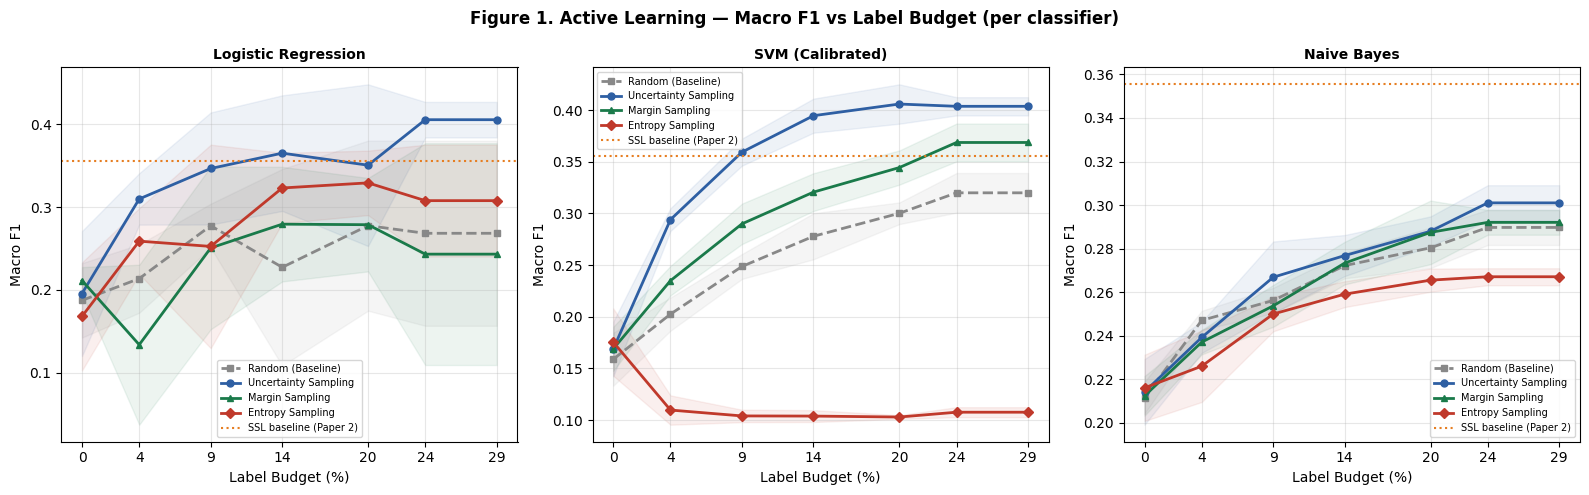

Figure 1 saved.


In [17]:
COLORS  = {'Random (Baseline)':    '#888888',
           'Uncertainty Sampling': '#2E5FA3',
           'Margin Sampling':      '#1A7A4A',
           'Entropy Sampling':     '#C0392B'}
LSTYLES = {'Random (Baseline)':'--',
           'Uncertainty Sampling':'-','Margin Sampling':'-','Entropy Sampling':'-'}
MARKERS = {'Random (Baseline)':'s',
           'Uncertainty Sampling':'o','Margin Sampling':'^','Entropy Sampling':'D'}
bpcts   = [int(k/N_POOL*100) for k in B_KEYS]

fig, axes = plt.subplots(1, 3, figsize=(16,5))
fig.suptitle('Figure 1. Active Learning — Macro F1 vs Label Budget (per classifier)',
             fontsize=12, fontweight='bold')

for ax, clf_name in zip(axes, CLASSIFIERS):
    for sn in STRATEGIES:
        vals = [all_results[(sn,clf_name)][k]['mf1']     for k in B_KEYS]
        stds = [all_results[(sn,clf_name)][k]['std_mf1'] for k in B_KEYS]
        ax.plot(bpcts, vals, marker=MARKERS[sn], ms=5,
                color=COLORS[sn], ls=LSTYLES[sn], lw=2, label=sn)
        ax.fill_between(bpcts,
                        [v-s for v,s in zip(vals,stds)],
                        [v+s for v,s in zip(vals,stds)],
                        alpha=0.08, color=COLORS[sn])
    ax.axhline(SSL_MACRO_F1, color='#E67E22', ls=':', lw=1.5,
               label=f'SSL baseline (Paper 2)')
    ax.set_xlabel('Label Budget (%)', fontsize=10)
    ax.set_ylabel('Macro F1', fontsize=10)
    ax.set_title(clf_name, fontsize=10, fontweight='bold')
    ax.set_xticks(bpcts)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('fig1_learning_curves.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show(); print('Figure 1 saved.')

## Cell 16 — Figure 2: Minority Class F1

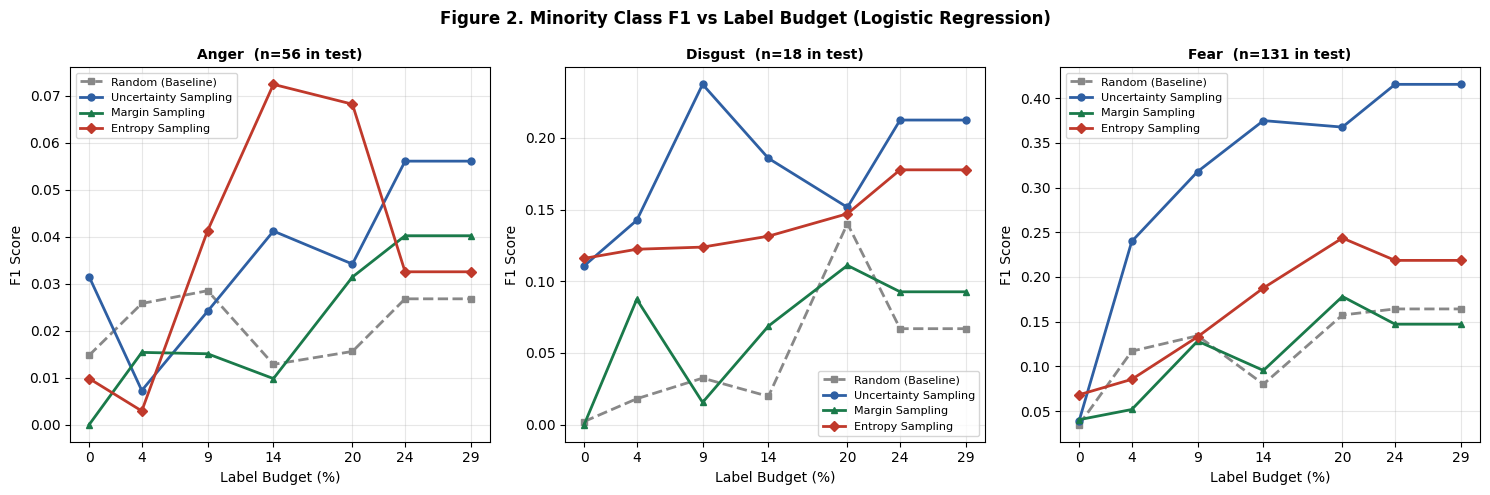

Figure 2 saved.


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
fig.suptitle('Figure 2. Minority Class F1 vs Label Budget (Logistic Regression)',
             fontsize=12, fontweight='bold')

clf_name = 'Logistic Regression'
for idx, mc in enumerate(['anger','disgust','fear']):
    ax = axes[idx]
    n_test = int((y_test==list(CLASS_NAMES).index(mc)).sum())
    for sn in STRATEGIES:
        vals = [all_results[(sn,clf_name)][k]['minority'][mc] for k in B_KEYS]
        ax.plot(bpcts, vals, marker=MARKERS[sn], ms=5,
                color=COLORS[sn], ls=LSTYLES[sn], lw=2, label=sn)
    ax.set_xlabel('Label Budget (%)', fontsize=10)
    ax.set_ylabel('F1 Score', fontsize=10)
    ax.set_title(f'{mc.capitalize()}  (n={n_test} in test)', fontsize=10, fontweight='bold')
    ax.set_xticks(bpcts)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig2_minority_f1.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show(); print('Figure 2 saved.')

## Cell 17 — Figure 3: Confusion Matrices at 30% Budget

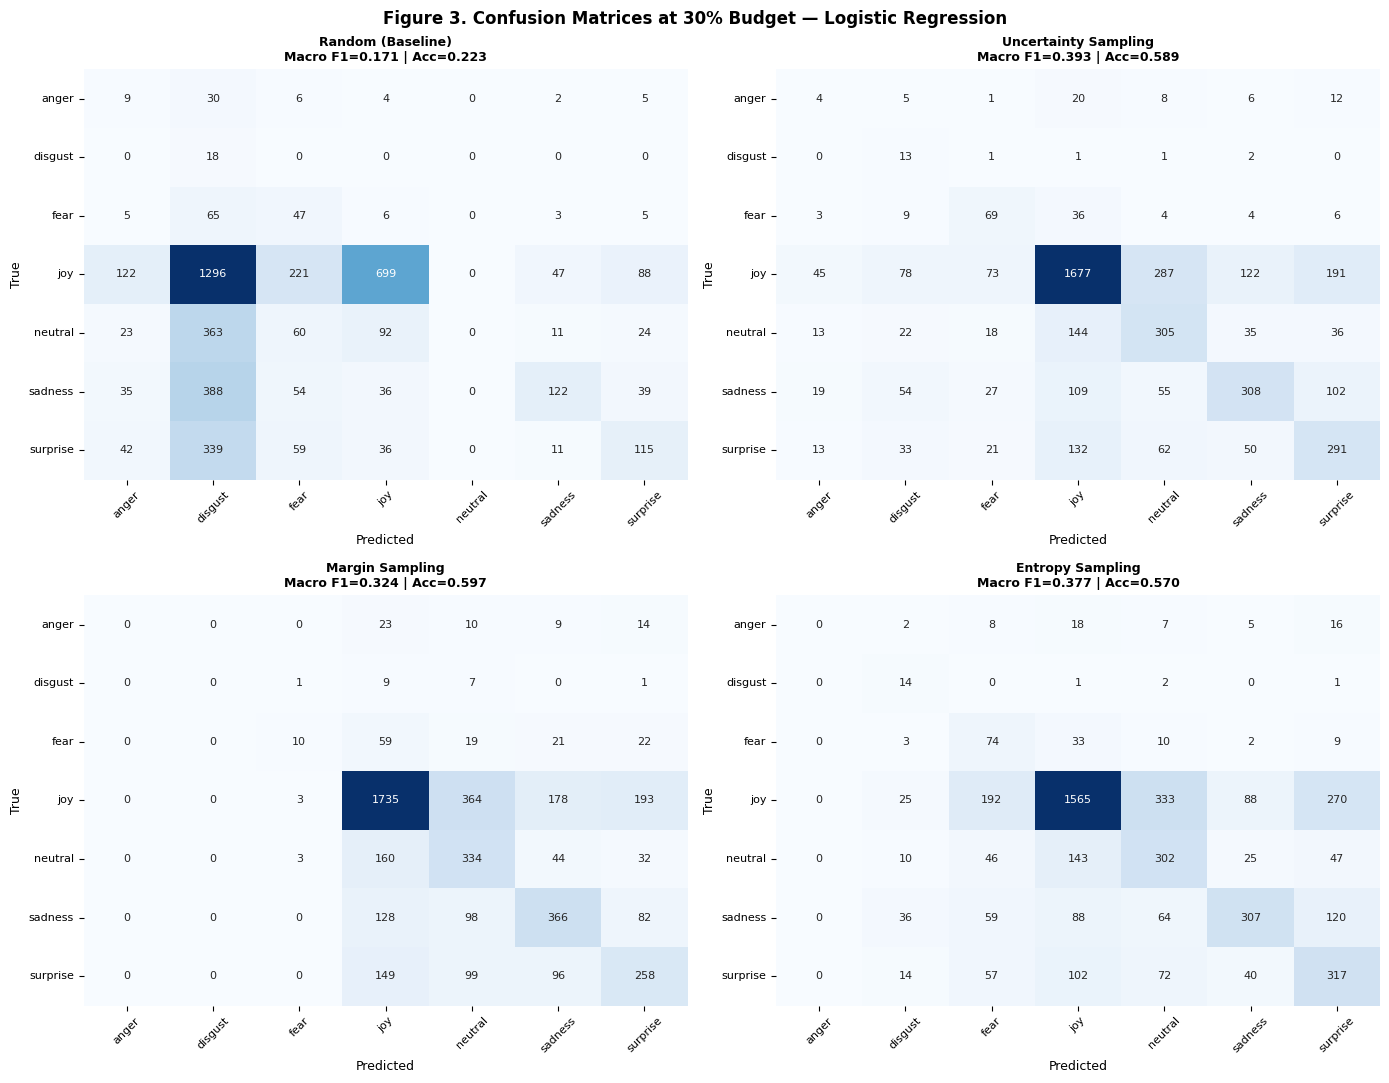

Figure 3 saved.


In [19]:
clf_name = 'Logistic Regression'
fig, axes = plt.subplots(2, 2, figsize=(14,11))
fig.suptitle(f'Figure 3. Confusion Matrices at 30% Budget — {clf_name}',
             fontsize=12, fontweight='bold')

for ax, sn in zip(axes.flatten(), STRATEGIES):
    yp = final_preds[(sn, clf_name)]
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, cbar=False, annot_kws={'size':8})
    mf1 = f1_score(y_test, yp, average='macro', zero_division=0)
    acc = accuracy_score(y_test, yp)
    ax.set_title(f'{sn}\nMacro F1={mf1:.3f} | Acc={acc:.3f}',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('fig3_confusion_matrices.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show(); print('Figure 3 saved.')

## Cell 18 — Figure 4: Grouped Bar Chart with Error Bars

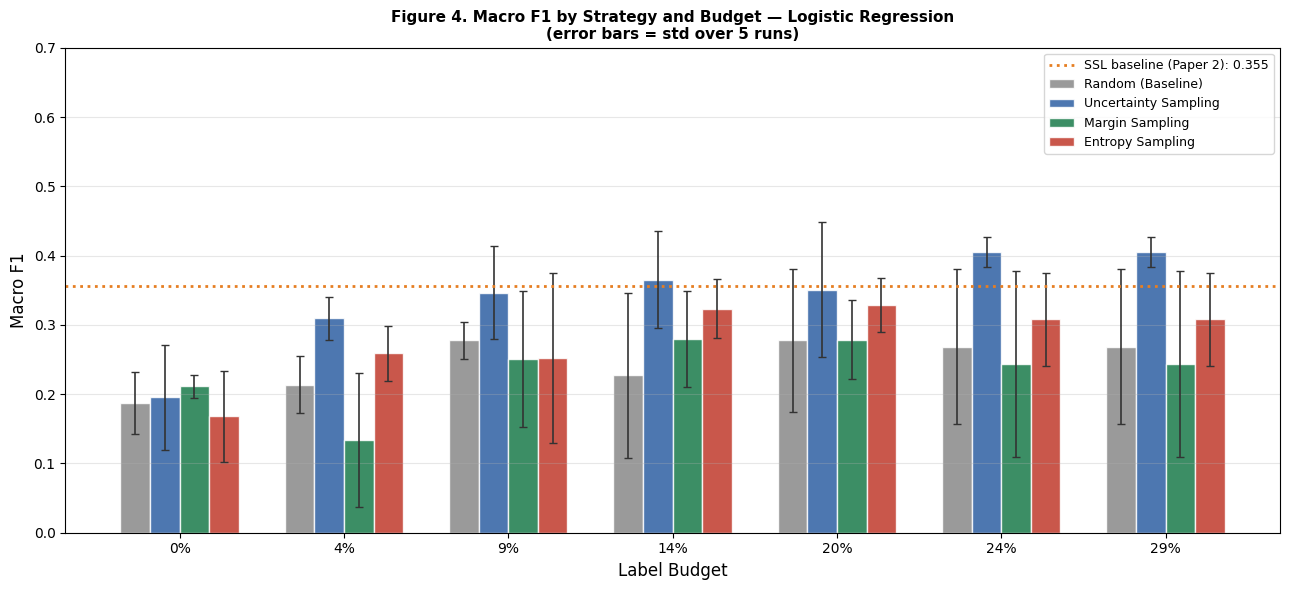

Figure 4 saved.


In [20]:
clf_name = 'Logistic Regression'
fig, ax  = plt.subplots(figsize=(13,6))
x     = np.arange(len(B_KEYS))
width = 0.18
offs  = np.linspace(-(len(STRATEGIES)-1)/2*width,
                     (len(STRATEGIES)-1)/2*width, len(STRATEGIES))

for (sn, _), off in zip(STRATEGIES.items(), offs):
    vals = [all_results[(sn,clf_name)][k]['mf1']     for k in B_KEYS]
    stds = [all_results[(sn,clf_name)][k]['std_mf1'] for k in B_KEYS]
    ax.bar(x+off, vals, width, label=sn, color=COLORS[sn], alpha=0.85,
           edgecolor='white', yerr=stds, capsize=3,
           error_kw={'elinewidth':1.2,'ecolor':'#333'})

ax.axhline(SSL_MACRO_F1, color='#E67E22', ls=':', lw=2,
           label=f'SSL baseline (Paper 2): {SSL_MACRO_F1:.3f}')
ax.set_xlabel('Label Budget', fontsize=12)
ax.set_ylabel('Macro F1', fontsize=12)
ax.set_title(f'Figure 4. Macro F1 by Strategy and Budget — {clf_name}\n(error bars = std over {N_RUNS} runs)',
             fontsize=11, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([f'{p}%' for p in bpcts])
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3); ax.set_ylim(0, 0.7)

plt.tight_layout()
plt.savefig('fig4_bar_chart.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show(); print('Figure 4 saved.')

## Cell 19 — Figure 5: Label Efficiency Curve

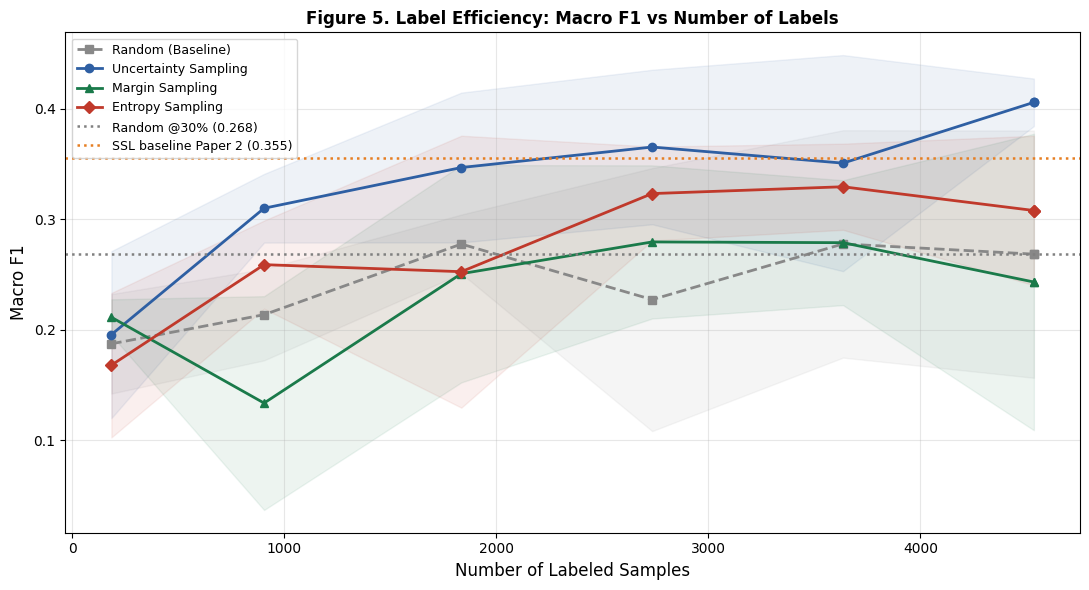

Figure 5 saved.


In [21]:
clf_name    = 'Logistic Regression'
rand_mf1_30 = all_results[('Random (Baseline)',clf_name)][b30]['mf1']

fig, ax = plt.subplots(figsize=(11,6))
for sn in STRATEGIES:
    vals    = [all_results[(sn,clf_name)][k]['mf1'] for k in B_KEYS]
    nlabels = [all_results[(sn,clf_name)][k]['n']   for k in B_KEYS]
    stds    = [all_results[(sn,clf_name)][k]['std_mf1'] for k in B_KEYS]
    ax.plot(nlabels, vals, marker=MARKERS[sn], ms=6,
            color=COLORS[sn], ls=LSTYLES[sn], lw=2, label=sn)
    ax.fill_between(nlabels, [v-s for v,s in zip(vals,stds)],
                    [v+s for v,s in zip(vals,stds)], alpha=0.08, color=COLORS[sn])

ax.axhline(rand_mf1_30, color='gray', ls=':', lw=1.8,
           label=f'Random @30% ({rand_mf1_30:.3f})')
ax.axhline(SSL_MACRO_F1, color='#E67E22', ls=':', lw=1.8,
           label=f'SSL baseline Paper 2 ({SSL_MACRO_F1:.3f})')
ax.set_xlabel('Number of Labeled Samples', fontsize=12)
ax.set_ylabel('Macro F1', fontsize=12)
ax.set_title('Figure 5. Label Efficiency: Macro F1 vs Number of Labels',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig5_label_efficiency.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show(); print('Figure 5 saved.')

## Cell 20 — Figure 6: Classifier Comparison at 30% Budget

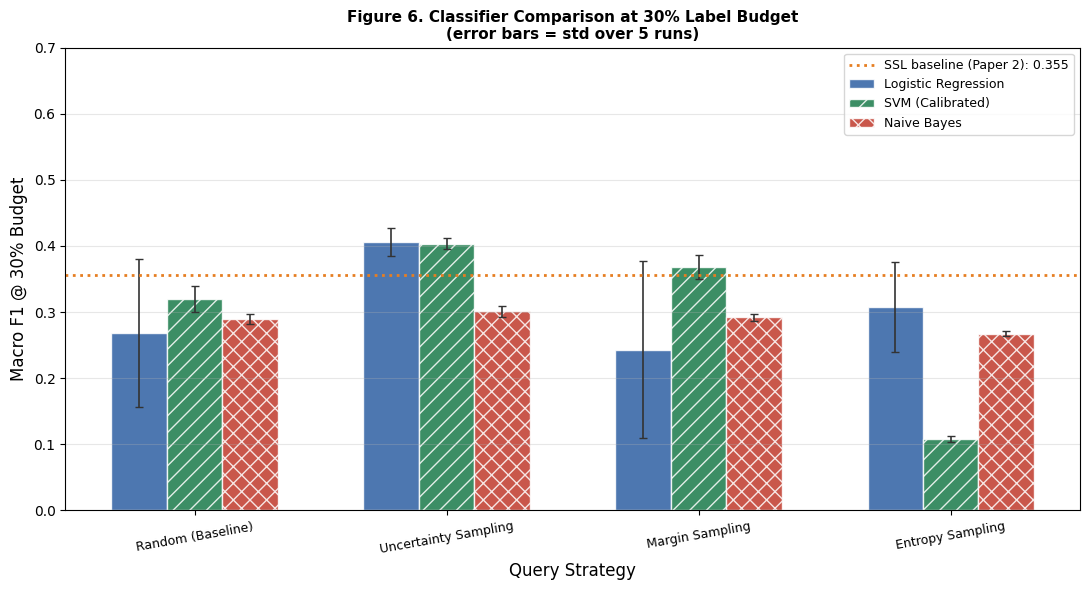

Figure 6 saved.


In [22]:
fig, ax = plt.subplots(figsize=(11,6))
CLF_COLORS = {'Logistic Regression':'#2E5FA3',
              'SVM (Calibrated)':    '#1A7A4A',
              'Naive Bayes':         '#C0392B'}
CLF_HATCH  = {'Logistic Regression':'',
              'SVM (Calibrated)':    '//',
              'Naive Bayes':         'xx'}

strat_labels = list(STRATEGIES.keys())
x     = np.arange(len(strat_labels))
width = 0.22
offs  = np.linspace(-(len(CLASSIFIERS)-1)/2*width,
                     (len(CLASSIFIERS)-1)/2*width, len(CLASSIFIERS))

for (clf_name, _), off in zip(CLASSIFIERS.items(), offs):
    vals = [all_results[(sn,clf_name)][b30]['mf1']     for sn in strat_labels]
    stds = [all_results[(sn,clf_name)][b30]['std_mf1'] for sn in strat_labels]
    ax.bar(x+off, vals, width, label=clf_name,
           color=CLF_COLORS[clf_name], hatch=CLF_HATCH[clf_name],
           alpha=0.85, edgecolor='white',
           yerr=stds, capsize=3, error_kw={'elinewidth':1.2,'ecolor':'#333'})

ax.axhline(SSL_MACRO_F1, color='#E67E22', ls=':', lw=2,
           label=f'SSL baseline (Paper 2): {SSL_MACRO_F1:.3f}')
ax.set_xlabel('Query Strategy', fontsize=12)
ax.set_ylabel('Macro F1 @ 30% Budget', fontsize=12)
ax.set_title('Figure 6. Classifier Comparison at 30% Label Budget\n(error bars = std over 5 runs)',
             fontsize=11, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(strat_labels, rotation=10, fontsize=9)
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3); ax.set_ylim(0, 0.7)

plt.tight_layout()
plt.savefig('fig6_classifier_comparison.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show(); print('Figure 6 saved.')

## Cell 21 — Figure 7: Statistical Significance Heatmap

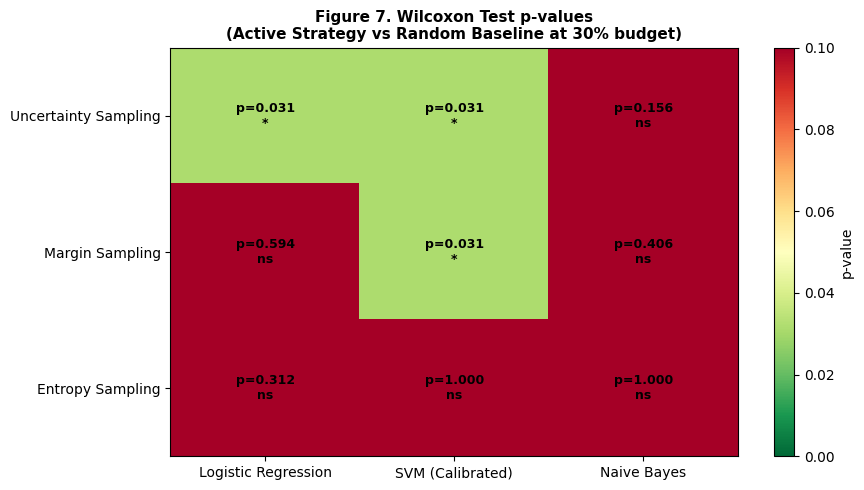

Figure 7 saved.


In [23]:
active_strats = ['Uncertainty Sampling','Margin Sampling','Entropy Sampling']
clf_names     = list(CLASSIFIERS.keys())

# Build p-value matrix
pval_matrix = np.zeros((len(active_strats), len(clf_names)))
for i, sn in enumerate(active_strats):
    for j, cn in enumerate(clf_names):
        pval_matrix[i,j] = sig_results.get((sn,cn), 1.0)

fig, ax = plt.subplots(figsize=(9,5))
im = ax.imshow(pval_matrix, cmap='RdYlGn_r', vmin=0, vmax=0.1, aspect='auto')
plt.colorbar(im, ax=ax, label='p-value')

ax.set_xticks(range(len(clf_names)))
ax.set_xticklabels(clf_names, fontsize=10)
ax.set_yticks(range(len(active_strats)))
ax.set_yticklabels(active_strats, fontsize=10)

for i in range(len(active_strats)):
    for j in range(len(clf_names)):
        p = pval_matrix[i,j]
        sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
        ax.text(j, i, f'p={p:.3f}\n{sig}',
                ha='center', va='center', fontsize=9, fontweight='bold')

ax.set_title('Figure 7. Wilcoxon Test p-values\n(Active Strategy vs Random Baseline at 30% budget)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_significance_heatmap.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show(); print('Figure 7 saved.')

## Cell 22 — Key Findings Summary

In [24]:
print('='*65)
print('  KEY FINDINGS SUMMARY')
print('='*65)

# Best strategy + classifier at 30%
best_combo = max(
    [(sn,cn) for sn in STRATEGIES for cn in CLASSIFIERS if sn!='Random (Baseline)'],
    key=lambda k: all_results[k][b30]['mf1'])
best_mf1   = all_results[best_combo][b30]['mf1']
rand_mf1   = all_results[('Random (Baseline)', best_combo[1])][b30]['mf1']
imp        = (best_mf1-rand_mf1)/max(rand_mf1,1e-9)*100

print(f'\n  Finding 1 — Best strategy at 30% budget')
print(f'  Best combination     : {best_combo[0]} + {best_combo[1]}')
print(f'  Macro F1 (best AL)   : {best_mf1:.3f}')
print(f'  Macro F1 (random)    : {rand_mf1:.3f}')
print(f'  Relative improvement : {imp:+.1f}%')
print(f'  SSL baseline (Paper2): {SSL_MACRO_F1:.3f}')
comp_ssl = (best_mf1-SSL_MACRO_F1)/max(SSL_MACRO_F1,1e-9)*100
print(f'  vs SSL baseline      : {comp_ssl:+.1f}%')

print(f'\n  Finding 2 — Label efficiency')
best_strat, best_clf = best_combo
for k in sorted(B_KEYS):
    v = all_results[(best_strat,best_clf)][k]['mf1']
    if v >= rand_mf1*0.97:
        pct    = int(k/N_POOL*100)
        saving = int((0.30-k/N_POOL)*N_POOL)
        print(f'  {best_strat} reaches random@30% at {pct}% budget')
        print(f'  Label saving: {saving:,} labels ({(0.30-k/N_POOL)/0.30*100:.0f}% reduction)')
        break

print(f'\n  Finding 3 — Minority class improvement at 30% budget')
for mc in ['anger','disgust','fear']:
    rv = all_results[('Random (Baseline)',best_clf)][b30]['minority'][mc]
    bv = all_results[(best_strat,best_clf)][b30]['minority'][mc]
    print(f'  {mc:<10}  Random={rv:.3f}  {best_strat}={bv:.3f}  (x{bv/max(rv,1e-9):.1f})')

print(f'\n  Finding 4 — Statistical significance')
for cn in CLASSIFIERS:
    p = sig_results.get((best_strat,cn),1.0)
    sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
    print(f'  {best_strat} vs Random | {cn}: p={p:.4f} {sig}')

print(f'\n  Reproducibility')
print(f'  Global seed : {GLOBAL_SEED}')
print(f'  N runs      : {N_RUNS}')
print(f'  Test size   : {X_test.shape[0]:,} samples ({TEST_SIZE*100:.0f}%)')
print(f'  Pool size   : {N_POOL:,} samples')
print(f'  Features    : {X_pool.shape[1]:,} TF-IDF')

  KEY FINDINGS SUMMARY

  Finding 1 — Best strategy at 30% budget
  Best combination     : Uncertainty Sampling + Logistic Regression
  Macro F1 (best AL)   : 0.406
  Macro F1 (random)    : 0.268
  Relative improvement : +51.2%
  SSL baseline (Paper2): 0.355
  vs SSL baseline      : +14.1%

  Finding 2 — Label efficiency
  Uncertainty Sampling reaches random@30% at 4% budget
  Label saving: 4,526 labels (83% reduction)

  Finding 3 — Minority class improvement at 30% budget
  anger       Random=0.027  Uncertainty Sampling=0.056  (x2.1)
  disgust     Random=0.067  Uncertainty Sampling=0.212  (x3.2)
  fear        Random=0.164  Uncertainty Sampling=0.415  (x2.5)

  Finding 4 — Statistical significance
  Uncertainty Sampling vs Random | Logistic Regression: p=0.0312 *
  Uncertainty Sampling vs Random | SVM (Calibrated): p=0.0312 *
  Uncertainty Sampling vs Random | Naive Bayes: p=0.1562 ns

  Reproducibility
  Global seed : 42
  N runs      : 5
  Test size   : 4,527 samples (20%)
  Pool si